# Class/Backend Processor

In [1]:
import numpy as np
import qutip as qt
from qutip import gates
from qutip_qip import *
from qiskit import QuantumCircuit
from qutip_qip.qiskit import QiskitCircuitSimulator
from qiskit.visualization import plot_histogram
from qutip_qip.device import LinearSpinChain
from qutip_qip.qiskit import QiskitPulseSimulator
from qutip_qip.device import Processor, Model
import warnings
warnings.filterwarnings('ignore')

In [2]:
from qiskit.compiler import transpile
from qutip_qip.circuit import QubitCircuit
from qutip_qip.qiskit.converter import convert_qiskit_circuit
from qiskit.visualization import plot_histogram

In [234]:
class minimal_processor( Processor ):
    def __init__(self, num_qubits=2, num_levels=4, decay_rate=1/(540e-6)):
        self.model = Model(2)
        self.num_qubits = num_qubits
        self.decay_rate = decay_rate
        self.native_gates = ["rx", "rz", "cz"]
        # basis states
        self.s0 = qt.tensor(qt.fock(2,0),qt.fock(2,0))
        self.s1 = qt.tensor(qt.fock(2,0),qt.fock(2,1))
        self.sr = qt.tensor(qt.fock(2,1),qt.fock(2,0))
        self.sd = qt.tensor(qt.fock(2,1),qt.fock(2,1))
        self.states = [self.s0, self.s1, self.sr, self.sd]
        self.b_0r = 1/16
        self.b_1r = 1/16
        self.b_dr = 7/8
        self.final_unitary_t = qt.tensor([qt.tensor(qt.qeye(2),qt.qeye(2)) for x in range(self.num_qubits)])
        self.circuit = None
        return

    def make_zero_density_matrix(self):
        zero_state = qt.tensor([qt.tensor(qt.zero_ket(2),qt.zero_ket(2)) for x in range(2)])
        return zero_state*zero_state.dag()

    def make_unitary_for_Qcircuit(self, index, partial_unitary, control_gate=False):
        if self.num_qubits == 1: return partial_unitary
        else:
            if control_gate: 
                tot_qubits = self.num_qubits - 1
                if tot_qubits == 1: return partial_unitary
            else: tot_qubits = self.num_qubits
            gates = [qt.tensor(qt.qeye(2),qt.qeye(2)) for x in range(tot_qubits)]
            gates[index] = partial_unitary
            return qt.tensor(gates)

    def calculate_system_H(self, Omega_01, delta_1, Omega_r, Delta_r):
        return

    def make_collapse_operators(self):
        operators = []
        for qn in range(self.num_qubits):
            gamma_r = self.decay_rate
            s0, s1, sr, sd = self.s0, self.s1, self.sr, self.sd
            L0 = np.sqrt(self.b_0r*gamma_r) * s0*sr.dag()
            L1 = np.sqrt(self.b_1r*gamma_r) * s1*sr.dag()
            Ld = np.sqrt(self.b_dr*gamma_r) * sd*sr.dag()
            operators += [self.make_unitary_for_Qcircuit(qn, L) for L in [L0, L1, Ld]]
        return operators

    def make_expectation_operators(self):
        operators = []
        for qn in range(self.num_qubits):
            #s0, s1, sr, sd = self.s0, self.s1, self.sr, self.sd
            operators += [self.make_unitary_for_Qcircuit(qn, s*s.dag()) for s in self.states]
        return operators
    
    def RX_gate(self, angle, target, rho):
        Omega_0 = 1e6
        delta_1 = 0
        Omega_r = 0
        Delta_r = 0
        s0, s1, sr, sd = self.s0, self.s1, self.sr, self.sd
        c_ops_input = self.make_collapse_operators()
        e_ops_input = self.make_expectation_operators()
        pulse_width = angle / Omega_0
        def Omega_01_Pulse(t, t_mid, pulse_width):
            half_pulse_width = pulse_width/2
            if (t_mid-half_pulse_width) <= t <= (t_mid+half_pulse_width): return Omega_0
            else: return 0
        tot_t = pulse_width
        midpoint_t = tot_t / 2
        steps = 1000
        dt = tot_t / 1000
        times = np.linspace(0.0, tot_t, steps+1) # This should be 10 seconds of microseconds?
        def H_Rx_gate(t):
            H = (Omega_01_Pulse(t, midpoint_t, pulse_width) / 2) * (s0*s1.dag() + s1*s0.dag())
            return self.make_unitary_for_Qcircuit(target, H)
        result = qt.mesolve(H_Rx_gate, rho, times, c_ops=c_ops_input, e_ops=e_ops_input, options={"store_states" : True, "store_final_state" : True})
        #unitary_t = qt.propagator(H_Rx_gate, angle*1e-6)
        return result#, unitary_t

    def RZ_gate(self, angle, target, rho):
        # Constants
        Omega_0 = 0
        delta_1 = 0
        Omega_r = 0
        Delta_r = 0
        s0, s1, sr, sd = self.s0, self.s1, self.sr, self.sd
        c_ops_input = self.make_collapse_operators()
        e_ops_input = self.make_expectation_operators()
        T = angle/2*1e-6
        def delta_1_t(t):
            if 0 <= t < T: return 1e6
            else: return 0
        tot_t = T
        midpoint_t = tot_t / 2
        steps = 1000
        dt = tot_t / steps
        times = np.linspace(0.0, tot_t, steps+1)
        def H_Rz_Gate(t):
            H = (delta_1_t(t)*s0*s0.dag()) - (delta_1_t(t)*s1*s1.dag())
            return self.make_unitary_for_Qcircuit(target, H)
        result = qt.mesolve(H_Rz_Gate, rho, times, c_ops=c_ops_input, e_ops=e_ops_input, options={"store_states" : True, "store_final_state" : True})
        #unitary_t = qt.propagator(H_Rz_Gate, angle*1e-6)
        return result#, unitary_t

    def CZ_gate(self, control, target, rho):
        # Constants
        T = 0.54e-6 # (microseconds^-1) period
        t0_0 = (T/2)
        t0_1 = t0_0 + T
        Omega_01 = 0 #MHz
        delta_1= 0 #MHz
        Omega_r= 2*np.pi*17e6 #MHz
        Delta_r= 2*np.pi*23e6 #MHz
        s0, s1, sr, sd = self.s0, self.s1, self.sr, self.sd
        tau = .175 * T
        def Omega_1r_t(t):
            if t < T/2: t0 = t0_0
            else: t0 = t0_1
            a = np.exp(-(t0/tau)**4)
            Omega_1r = Omega_r * (np.exp(-((t-t0)**4) / tau**4) - a) / (1-a)
            return Omega_1r
        def Delta_r_t(t):
            t = t % (T/2)
            return -Delta_r * np.cos((2*np.pi / T) * t)
        c_ops = self.make_collapse_operators()
        e_ops = self.make_expectation_operators()
        #B = 2*np.pi*201.32753861e6 # MHz
        B = 2*np.pi*1000e6 # MHz
        def H_CZ(t):
            H_B = B * qt.tensor([sr,sr])*qt.tensor([sr,sr]).dag()
            H0 = ((Omega_01 / 2) * (s0*s1.dag() + s1*s0.dag())) + (delta_1*s1*s1.dag()) + ((Omega_1r_t(t)/2) * (s1*sr.dag() + (sr*s1.dag()))) + (Delta_r_t(t)*sr*sr.dag())
            H1 = ((Omega_01 / 2) * (s0*s1.dag() + s1*s0.dag())) + (delta_1*s1*s1.dag()) + ((Omega_1r_t(t)/2) * (s1*sr.dag() + (sr*s1.dag()))) + (Delta_r_t(t)*sr*sr.dag())
            H = qt.tensor([H0, qt.tensor(qt.qeye(2), qt.qeye(2))]) + qt.tensor([qt.tensor(qt.qeye(2), qt.qeye(2)), H1]) + H_B
            if control < target: return self.make_unitary_for_Qcircuit(control, H, control_gate=True)
            else: return self.make_unitary_for_Qcircuit(target, H, control_gate=True)
        tot_t = T
        steps = 1000
        dt = tot_t / steps
        tot_t = tot_t - dt
        times = np.linspace(0.0, tot_t, steps+1)
        result = qt.mesolve(H_CZ, rho, times, c_ops=c_ops, e_ops=e_ops, options={"store_states" : True, "store_final_state" : True})
        #unitary_t = qt.propagator(H_CZ, T, options={"nsteps":100000})
        return result#, unitary_t

    def generate_init_processor_state(self):
        list_qubit_states = [qt.tensor(qt.fock(2,0),qt.fock(2,0)) for x in range(self.num_qubits)]
        return qt.tensor(list_qubit_states)

    def load_circuit(self, qutip_circuit):
        print("Circuit Loaded")
        #print(qutip_circuit.gates)
        self.circuit = qutip_circuit
        return 

    def run_state(self, init_state, qutip_circuit=None):
        result = None
        curr_state = init_state
        if len(self.circuit.gates) == 0:
            result = self.RX_gate(0, 0, curr_state)
        else: 
            for gate in self.circuit.gates:
                H = 0
                #print(gate.name, gate.arg_value)
                if gate.name == "RX": result = self.RX_gate(gate.arg_value, gate.targets[0], curr_state)
                elif gate.name == "RZ": result = self.RZ_gate(gate.arg_value, gate.targets[0], curr_state)
                elif gate.name == "CZ": result = self.CZ_gate(gate.controls[0], gate.targets[0], curr_state)
                else: print("Incompatiable Gate")
                curr_state = result.final_state
            #self.final_unitary_t = self.final_unitary_t * unitary_t
        #print(result.final_state)
        return result

    def get_final_circuit_state(self, final_state):
        dims_list = [2*x+1 for x in range(self.num_qubits)]
        return final_state.ptrace(dims_list)

# Randomized Bench Dependencies

In [144]:
import numpy as np
from qiskit_experiments.library import StandardRB, InterleavedRB
from qiskit_experiments.framework import ParallelExperiment, BatchExperiment
import qiskit.circuit.library as circuits

# Exercise 3

In [199]:
processor1Q = minimal_processor(1)
backend1Q = QiskitPulseSimulator(processor1Q)

In [200]:
lengths = np.arange(1, 10, 1)
num_samples = 10
seed = 1010
qubits = [0]

In [201]:
exp1 = StandardRB(qubits, lengths, num_samples=num_samples, seed=seed)
exp1.set_transpile_options(optimization_level=1, basis_gates=["rx", "rz", "cz"])

exp1._set_backend(backend1Q)
exp1._finalize()

transpiled_circuits = exp1._transpiled_circuits()
print(transpiled_circuits[0])

experimental_data = exp1._initialize_experiment_data()
run_opts = exp1.run_options.__dict__
_ = [this_circ.remove_final_measurements() for this_circ in transpiled_circuits]
jobs = [exp1._run_jobs(this_circ, **run_opts)[0] for this_circ in transpiled_circuits]

for i,job in enumerate(jobs):
    d = job.result().results[0].header.to_dict()
    d["metadata"] = transpiled_circuits[i].metadata
    job.result().results[0].header.from_dict(d)

global phase: 3π/2
        ┌──────────┐┌───────┐ ░ ┌──────────┐┌───────┐ ░ ┌─┐
     q: ┤ Rz(-π/2) ├┤ Rx(π) ├─░─┤ Rz(-π/2) ├┤ Rx(π) ├─░─┤M├
        └──────────┘└───────┘ ░ └──────────┘└───────┘ ░ └╥┘
meas: 1/═════════════════════════════════════════════════╩═
                                                         0 


In [202]:
experimental_data.add_jobs(jobs)

In [203]:
exp1.analysis.run(experimental_data)

ExperimentData(StandardRB, 07644627-9921-4b70-b4d2-8fd0ccae77be, job_ids=['7d606ab0-5032-4bef-87a7-5927ee23f702', '47055665-a411-4e6d-9e27-6f24bbe67c07', '0877bc49-7ca2-4e39-8841-a0cdb45d4819', 'e0ced44c-d7a2-4a8a-a5c3-e9ac030e4d88', '5bb7408d-decf-47ca-b2a9-61209d404138', 'fcdb0faa-b244-4d91-b951-447d491e10d0', '34beacc6-842a-4f4a-9e54-a83f4299d896', '610d24d4-7ce2-40c0-ad05-8467e9c109be', 'b43c36e7-f2d8-4d04-bf52-3e02824bd3fd', 'ecb41adc-6997-4f3f-abac-468caac35c19', '65743fb8-373e-4395-9e82-c1084f19ead4', '93472ca8-4434-453e-9273-f38f6a8a4f20', 'eff01676-202e-4128-846d-fa06816a7aca', 'baca3476-75f7-41d0-896f-bbd54b95f507', '11d67a0f-e2a4-447b-95f2-a429092c8744', 'c5a254c4-89c8-4a6f-9149-6f7c81730c93', '8142e907-724c-4ff2-95fe-017e752891cd', '29094b2e-8525-4401-b090-8894b04124df', '4ada4970-d38b-4028-b472-337998602b19', '09974e72-80e5-4829-a312-27e8486183fa', '3cd31090-cac5-4171-810d-e1e880661e95', 'e385d19e-606f-4738-92e9-88d702e1143b', '13dccfd9-3c21-442e-a5ce-87c7d4ce13f4', '75114

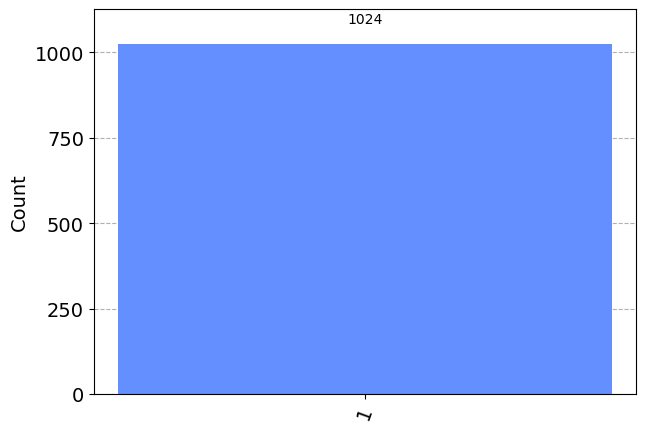

In [204]:
pulse_result = job.result()
plot_histogram(pulse_result.get_counts())

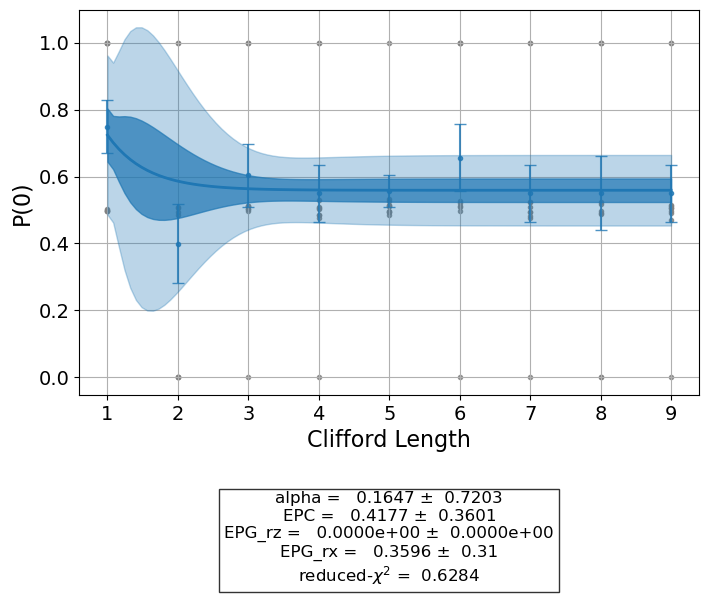

In [205]:
display(experimental_data.figure(0))

In [206]:
display(experimental_data.analysis_results(dataframe=True))

,name,experiment,components,value,quality,backend,run_time,chisq
f59b0100,@Parameters_RBAnalysis,StandardRB,[Q0],CurveFitResult:\n - fitting method: least_squa...,good,pulse_simulator,None,None
a0387cbf,alpha,StandardRB,[Q0],0.2+/-0.7,good,pulse_simulator,None,0.628436
96540ecd,EPC,StandardRB,[Q0],0.4+/-0.4,good,pulse_simulator,None,0.628436
a3bdfca1,EPG_rz,StandardRB,[Q0],0.0+/-0,good,pulse_simulator,None,0.628436
3233f358,EPG_rx,StandardRB,[Q0],0.36+/-0.31,good,pulse_simulator,None,0.628436


My EPC is .4 +/- .4

My previous fidelity was near 1 during my rx rz pi pulse tests

My current EPC is most likely due to low sampling

# Exercise 4

In [207]:
processor2Q = minimal_processor(2)
backend2Q = QiskitPulseSimulator(processor2Q)

In [211]:
np.arange(1, 10, 10)

array([1])

In [212]:
lengths_2_qubit = np.arange(1, 2, 1)
lengths_1_qubit = np.arange(1, 2, 1)
num_samples = 1
seed = 1010
qubits = (1, 2)

In [213]:
exp2 = StandardRB(qubits, lengths, num_samples=num_samples, seed=seed)
exp2.set_transpile_options(optimization_level=1, basis_gates=["rx", "rz", "cz"])

exp2._set_backend(backend2Q)
exp2._finalize()

transpiled_circuits = exp2._transpiled_circuits()
print(transpiled_circuits[0])

experimental_data2 = exp2._initialize_experiment_data()
run_opts = exp2.run_options.__dict__
_ = [this_circ.remove_final_measurements() for this_circ in transpiled_circuits]
jobs = [exp2._run_jobs(this_circ, **run_opts)[0] for this_circ in transpiled_circuits]

for i,job in enumerate(jobs):
    d = job.result().results[0].header.to_dict()
    d["metadata"] = transpiled_circuits[i].metadata
    job.result().results[0].header.from_dict(d)

global phase: π/4
                                                                             »
   q_0: ─────────────────────────────────────────────────────────────────────»
        ┌─────────┐                         ┌─────────┐┌─────────┐┌─────────┐»
   q_1: ┤ Rz(π/2) ├───────────────────────■─┤ Rz(π/2) ├┤ Rx(π/2) ├┤ Rz(π/2) ├»
        ├─────────┤┌─────────┐┌─────────┐ │ ├─────────┤├─────────┤├─────────┤»
   q_2: ┤ Rz(π/2) ├┤ Rx(π/2) ├┤ Rz(π/2) ├─■─┤ Rz(π/2) ├┤ Rx(π/2) ├┤ Rz(π/2) ├»
        └─────────┘└─────────┘└─────────┘   └─────────┘└─────────┘└─────────┘»
meas: 2/═════════════════════════════════════════════════════════════════════»
                                                                             »
«                                                                       »
«   q_0: ───────────────────────────────────────────────────────────────»
«           ┌─────────┐  ┌───────┐            ░ ┌──────────┐┌──────────┐»
«   q_1: ─■─┤ Rz(π/2) ├──┤ Rx(π) ├────────────░─┤

In [214]:
experimental_data2.add_jobs(jobs, timeout=None)

In [215]:
exp2.analysis.set_options(outcome="0")

In [216]:
expdata1_2q = exp2.analysis.run(experimental_data2, gate_error_ratio=False)

In [217]:
results1_2q = expdata1_2q.analysis_results()

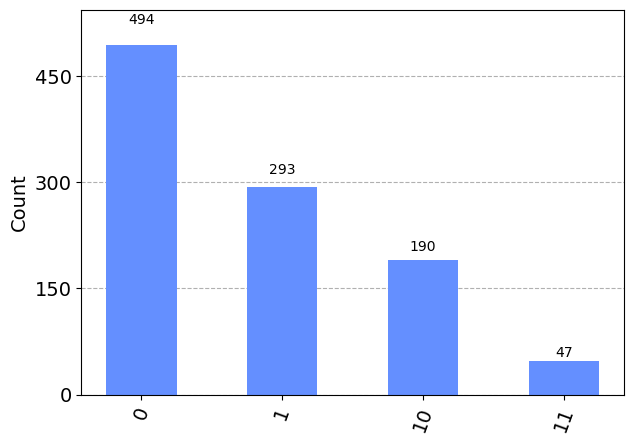

In [218]:
pulse_result = job.result()
plot_histogram(pulse_result.get_counts())

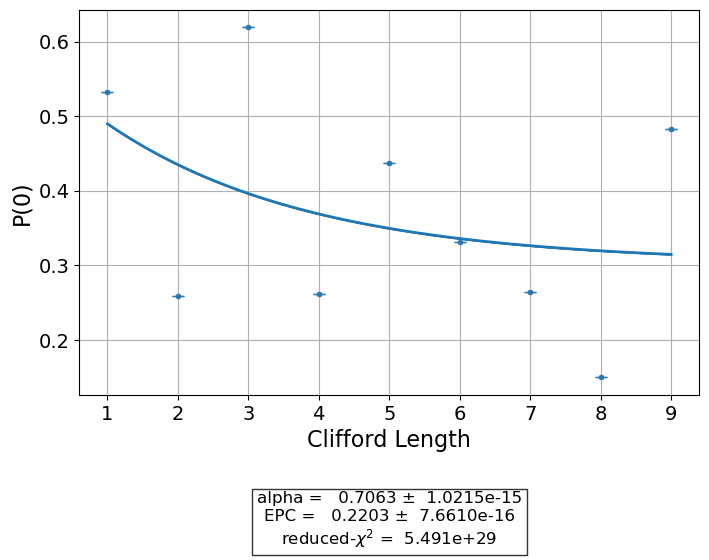

In [219]:
display(experimental_data2.figure(0))

In [223]:
display(experimental_data2.analysis_results(dataframe=True))

,name,experiment,components,value,quality,backend,run_time,chisq
1e7faf3b,@Parameters_RBAnalysis,StandardRB,"[Q1, Q2]",CurveFitResult:\n - fitting method: least_squa...,bad,pulse_simulator,None,None
1e4654b5,alpha,StandardRB,"[Q1, Q2]",0.7062780414832834+/-0.0000000000000010,bad,pulse_simulator,None,549077723952707179485627154432.0
12ba5aa8,EPC,StandardRB,"[Q1, Q2]",0.2202914688875374+/-0.0000000000000008,bad,pulse_simulator,None,549077723952707179485627154432.0


If my original fidelity for CZ was correct at .9 then it should be roughly 1/.9 clifford length. But most likely it is closer to .5 then length 2 seems correct. Honestly the length measurement was rather unclear from the docs and I mostly had to assume 1 or zero for most values correlated to our rx and rz gates.

The population is less in the zero state and clearly a much higher error (bad quality fit). It should be comparable to my orginal fidelity as well which does seem to be the case based on how I initially defined it in module 2. I also got around .2 fidelity for the gate there as well before ptracing

# Exercise 5

In [207]:
processor2Q = minimal_processor(2)
backend2Q = QiskitPulseSimulator(processor2Q)

In [235]:
lengths = np.arange(1, 4, 1)
num_samples = 2
seed = 1010
qubits = (1, 2)

# The interleaved gate is the CX gate
int_exp2 = InterleavedRB(circuits.CZGate(), qubits, lengths, num_samples=num_samples, seed=seed)
int_exp2.set_transpile_options(optimization_level=1, basis_gates=["rx", "rz", "cz"])

int_exp2._set_backend(backend2Q)
int_exp2._finalize()

transpiled_circuits = int_exp2._transpiled_circuits()
print(transpiled_circuits[0])

int_expdata2 = int_exp2._initialize_experiment_data()
run_opts = int_exp2.run_options.__dict__
_ = [this_circ.remove_final_measurements() for this_circ in transpiled_circuits]
jobs = [int_exp2._run_jobs(this_circ, **run_opts)[0] for this_circ in transpiled_circuits]

for i,job in enumerate(jobs):
    print("Job {} Done".format(i))
    d = job.result().results[0].header.to_dict()
    d["metadata"] = transpiled_circuits[i].metadata
    job.result().results[0].header.from_dict(d)

global phase: π/4
                                                                             »
   q_0: ─────────────────────────────────────────────────────────────────────»
        ┌─────────┐                         ┌─────────┐┌─────────┐┌─────────┐»
   q_1: ┤ Rz(π/2) ├───────────────────────■─┤ Rz(π/2) ├┤ Rx(π/2) ├┤ Rz(π/2) ├»
        ├─────────┤┌─────────┐┌─────────┐ │ ├─────────┤├─────────┤├─────────┤»
   q_2: ┤ Rz(π/2) ├┤ Rx(π/2) ├┤ Rz(π/2) ├─■─┤ Rz(π/2) ├┤ Rx(π/2) ├┤ Rz(π/2) ├»
        └─────────┘└─────────┘└─────────┘   └─────────┘└─────────┘└─────────┘»
meas: 2/═════════════════════════════════════════════════════════════════════»
                                                                             »
«                                                                       »
«   q_0: ───────────────────────────────────────────────────────────────»
«           ┌─────────┐  ┌───────┐            ░ ┌──────────┐┌──────────┐»
«   q_1: ─■─┤ Rz(π/2) ├──┤ Rx(π) ├────────────░─┤

In [236]:
int_expdata2.add_jobs(jobs, timeout=None)

In [237]:
int_exp2.analysis.set_options(outcome="0")

In [238]:
int_expdata2_2q = int_exp2.analysis.run(int_expdata2, gate_error_ratio=False)

In [239]:
int_results1_2q = int_expdata2_2q.analysis_results()

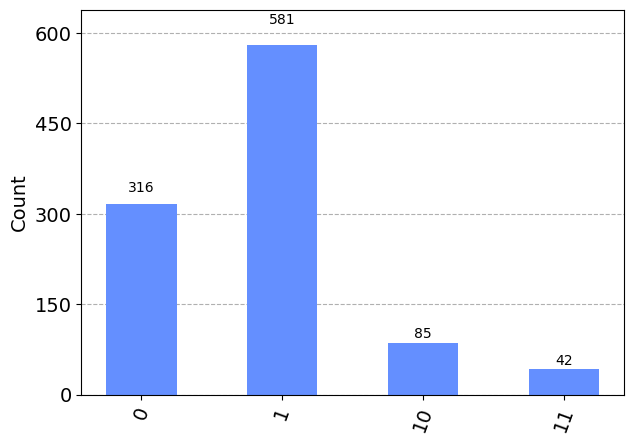

In [240]:
pulse_result = job.result()
plot_histogram(pulse_result.get_counts())

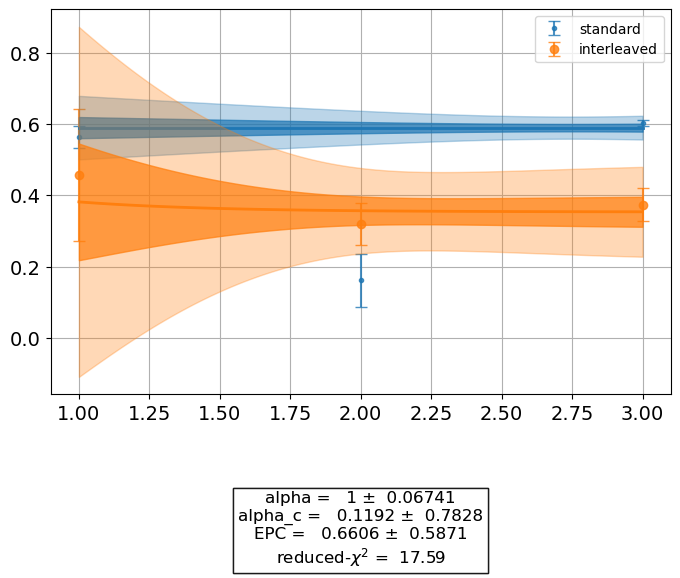

In [241]:
display(int_expdata2.figure(0))

In [242]:
display(int_expdata2.analysis_results(dataframe=True))

,name,experiment,components,value,quality,backend,run_time,chisq,EPC_systematic_err,EPC_systematic_bounds
2c18d6b9,@Parameters_InterleavedRBAnalysis,InterleavedRB,"[Q1, Q2]",CurveFitResult:\n - fitting method: least_squa...,bad,pulse_simulator,None,None,None,None
ebc4db05,alpha,InterleavedRB,"[Q1, Q2]",1.00+/-0.07,bad,pulse_simulator,None,17.594337,None,None
7e8a995d,alpha_c,InterleavedRB,"[Q1, Q2]",0.1+/-0.8,bad,pulse_simulator,None,17.594337,None,None
86a934b5,EPC,InterleavedRB,"[Q1, Q2]",0.7+/-0.6,bad,pulse_simulator,None,17.594337,0.0,"[0.6605637519293845, 0.6605640783974698]"
